# EDA: E-commerce UK

Análise completa de **541 mil transações** de uma loja de varejo online britânica. Os dados vão de 12/2019 - 12/2011.

Dataset utilizado: [E-commerce Data](https://www.kaggle.com/datasets/carrie1/ecommerce-data)

**Github**: [Github](https://github.com/victorxavier01)

**LinkedIn**: [LinkedIn](https://www.linkedin.com/in/victor-xavier-89a339378/)

**Medium**: [Medium](https://medium.com/@lvsxmk23)

## Objetivos:
- **Entender a saúde financeira**
- **Mapear sazonalidade**
- **Analisar devoluções**
- **Gerar insights**

**O que será usado:**
- **Pandas**
- **Numpy**
- **Plotly, seaborn, matplotlib para visualização**
- **Scikit-learn para regressão linear**

## Sumário

- [1. Carregamento e limpeza](#limpeza)
- [2. KPIs e tendencias](#kpis)
- [3. Análises de Produtos](#produtos)
- [4. Análise Geográfica](#geografia)
- [5. Análise de cancelamentos](#cancelamentos)
- [6. Análise por Dia da Semana](#dia-semana)
- [7. Cliente Ativo ao Longo do Tempo](#clientes-ativos)
- [8. Insights](#insights)

In [1]:
# Importações
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Configurações de estilo do plotly
px.defaults.template = 'plotly_white'
px.defaults.width = 900
px.defaults.height = 500

# Paths
DATA_PATH = 'data/data.csv'
RESULTS_DIR = 'results/charts'

<div id="limpeza"></div>

## 1. Carregamento e limpeza


In [2]:
# Carregando e exploração inicial

df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1')

# Quantidade de linhas e colunas
print(f"Linhas: {len(df):,} | Colunas: {len(df.columns)}")

# Datatypes
print(f"\nDataset:\n\n{df.dtypes}")

# Nulos
print(f"\nNulos:\n\n{df.isnull().sum()}")

# Clientes únicos
print(f"\nTotal de clientes únicos:\n\n {df['CustomerID'].dropna().nunique():,}")

# Países
print(f"\nPaíses:\n\n {df['Country'].nunique()}")

df.head(3).style.set_caption('Primeiras 3 transações')

Linhas: 541,909 | Colunas: 8

Dataset:

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

Nulos:

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Total de clientes únicos:

 4,372

Países:

 38


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.550000,17850.000000,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.390000,17850.000000,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.750000,17850.000000,United Kingdom


In [92]:
# Limpeza e Feature Engineering

# Convertendo string para data
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Criando coluna receita

df['total'] = df['Quantity'] * df['UnitPrice']

# Algumas transições são positivas e outras negativas, o que da a entender que as positivas são vendas e as negativas são devoluções. Vamos separá-las.
# Isso é essencial para alguns cálculos, como por exemplo o do ticket médio. Também é essencial para treinar modelos
df_vendas = df[df['Quantity'] > 0].copy()
df_devolucoes = df[df['Quantity'] < 0].copy()

# Features temporais
df_features = df.copy()
df_features['ano'] = df['InvoiceDate'].dt.year
df_features['mes'] = df['InvoiceDate'].dt.month
df_features['semana'] = df['InvoiceDate'].dt.isocalendar().week.astype(int)
df_features['dia_semana'] = df['InvoiceDate'].dt.day_name()
df_features['mes_nome'] = df['InvoiceDate'].dt.strftime('%b')

df_vendas['ano'] = df_vendas['InvoiceDate'].dt.year
df_vendas['mes_nome'] = df_vendas['InvoiceDate'].dt.strftime('%b')

print(f"Vendas: {len(df_vendas):,} linhas | Devoluções: {len(df_devolucoes):,} linhas")
print(f"Total de devoluções: {len(df_devolucoes):,} itens em {df_devolucoes['InvoiceDate'].nunique():,} notas")

Vendas: 531,285 linhas | Devoluções: 10,624 linhas
Total de devoluções: 10,624 itens em 4,851 notas


In [4]:
# Explorando mais o DF original

print(f"---Resumo dos preços--- \n\n{df['UnitPrice'].describe()}")
print(f"\n---Resumo das quantidades--- \n\n{df['Quantity'].describe()}")
print(f"\nProdutos únicos:\n\n {df['StockCode'].nunique():,}")
print(f"\nDescrições únicas:\n\n {df['Description'].nunique():,}")

---Resumo dos preços--- 

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

---Resumo das quantidades--- 

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

Produtos únicos:

 4,070

Descrições únicas:

 4,223


<div id="kpis"></div>

## 2. KPIs


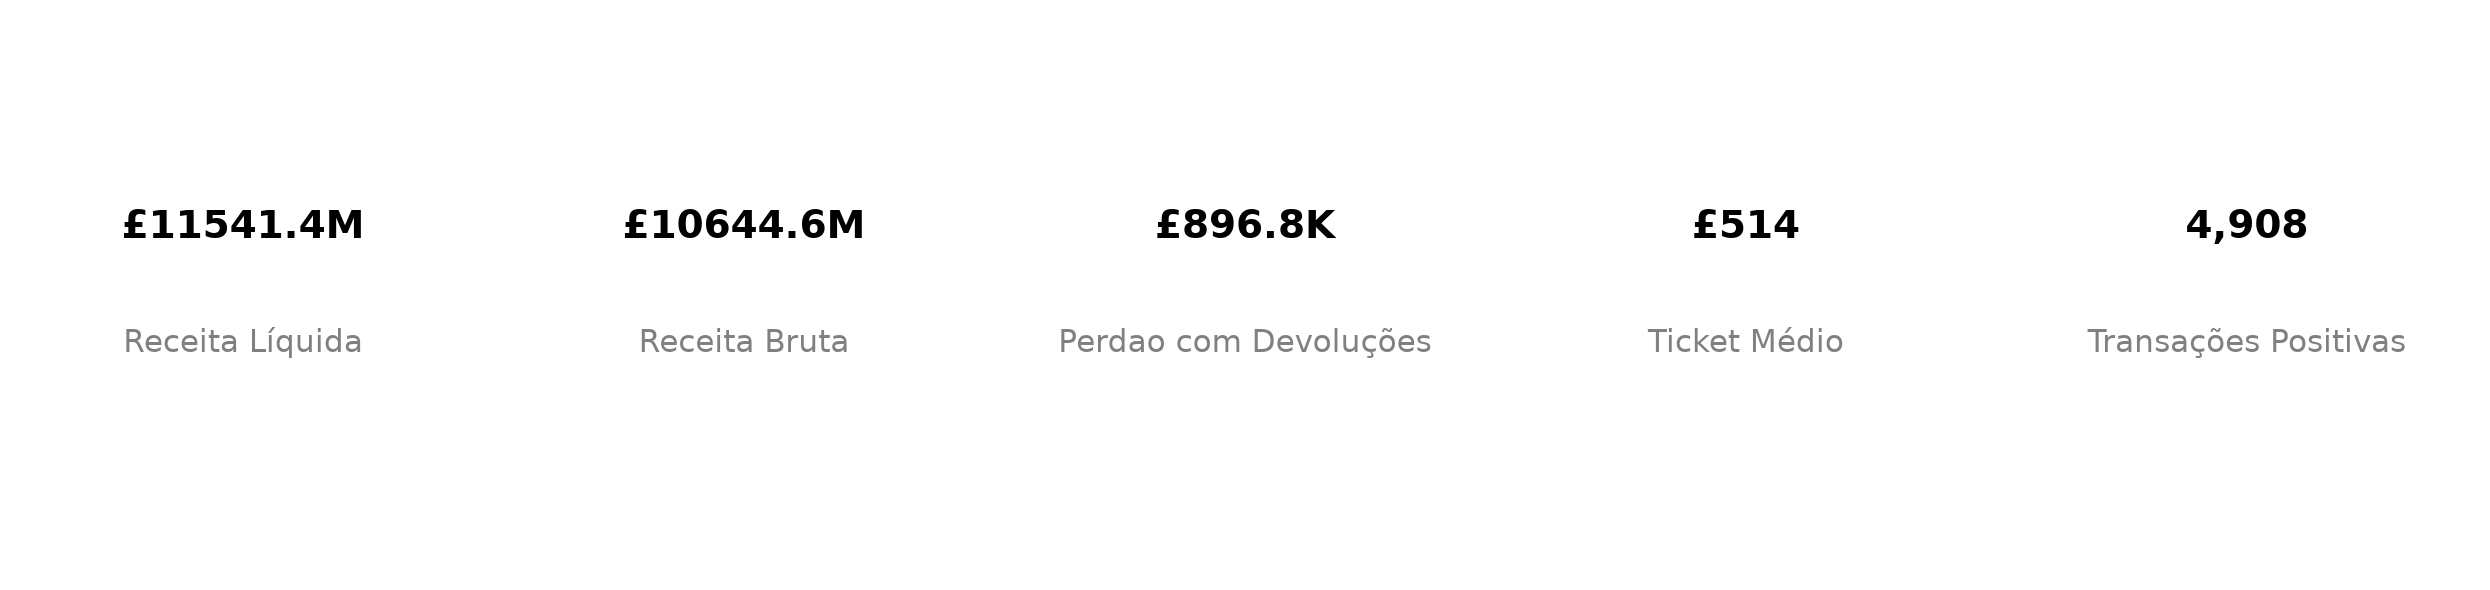


Taxa de Devolução (valores): £896,812.49 (8.4% da receita bruta)


In [20]:
# Kpis

receita_bruta = df_vendas['total'].sum()
receita_liquida = abs(df_vendas['total'].sum()) + abs(df_devolucoes['total'].sum())
perda_devolucoes = abs(df_devolucoes['total'].sum())
ticket_medio = df_vendas.groupby('InvoiceNo')['total'].sum().mean()
n_transacoes = df_vendas['total'].nunique()
n_clientes = df_vendas['CustomerID'].dropna().nunique()

# Cards dos KPIs
fig, axes = plt.subplots(1, 5, figsize=(25,6))

kpis = [
    (f'£{receita_liquida/1000:.1f}M', 'Receita Líquida'),
    (f'£{receita_bruta/1000:.1f}M', 'Receita Bruta'),
    (f'£{perda_devolucao/1000:.1f}K', 'Perdao com Devoluções'),
    (f'£{ticket_medio:.0f}', 'Ticket Médio'),
    (f'{n_transacoes:,}', 'Transações Positivas')
]

for ax, (valor,titulo) in zip(axes, kpis):
    ax.text(0.5, 0.6, valor, fontsize=28, fontweight='bold', ha='center')
    ax.text(0.5, 0.4, titulo, fontsize=22, ha='center', color='gray')
    ax.set_axis_off()

plt.tight_layout()

plt.show()

print(f"\nTaxa de Devolução (valores): £{perda_devolucoes:,.2f} ({perda_devolucoes/receita_bruta*100:.1f}% da receita bruta)")

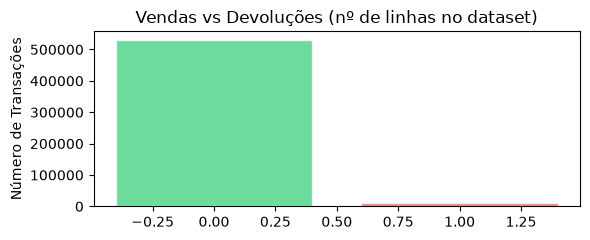


Cliente Ativo: 4,339  |  ARPU: £2,659.92


In [30]:
fig, ax = plt.subplots(figsize=(6,2.5))

# Barra de devolução
ax.bar([0, 1], [len(df_vendas), len(df_devolucoes)], color=colors, alpha=0.7, edgecolor='white')
ax.set_ylabel('Número de Transações')
ax.set_title('Vendas vs Devoluções (nº de linhas no dataset)')

plt.tight_layout()
plt.show()

print(f"\nCliente Ativo: {n_clientes:,}  |  ARPU: £{receita_liquida/n_clientes:,.2f}")


<div id="evolucao"></div>

## 3. Evolução Temporal

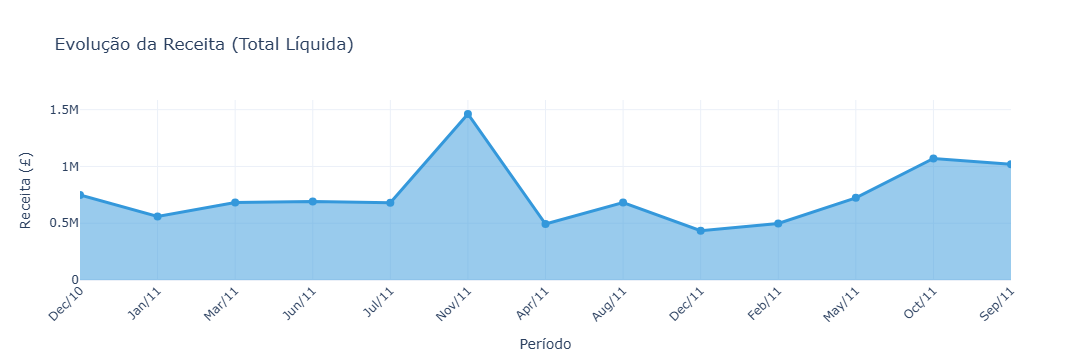

In [43]:
# Receita mensal
receita_mensal = df_features.groupby(['ano', 'mes_nome']).agg(
    receita=('total', 'sum'),
    n_transacoes=('InvoiceNo', 'count')
).reset_index()


meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

receita_mensal['mes_pedido'] = pd.Categorical(receita_mensal['mes_nome'], categories=meses, ordered=True)
receita_mensal = receita_mensal.sort_values(['ano', 'mes_pedido'])


receita_mensal['eixo_x'] = receita_mensal['mes_nome'] + '/' + receita_mensal['ano'].astype(str).str[-2:]


fig = go.Figure()

fig.add_trace(go.Scatter(
    x=receita_mensal['eixo_x'],
    y=receita_mensal['receita'],
    mode='lines+markers',
    name='Receita',
    line=dict(color='#3498db', width=3),
    marker=dict(size=8),
    fill='tozeroy',
    hovertemplate='Mês/Ano: %{x}<br>Receita: £%{y:,.2f}<extra></extra>'
))

fig.update_layout(
    title='Evolução da Receita (Total Líquida)',
    xaxis_title='Período',
    yaxis_title='Receita (£)',
    xaxis_tickangle=-45,
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

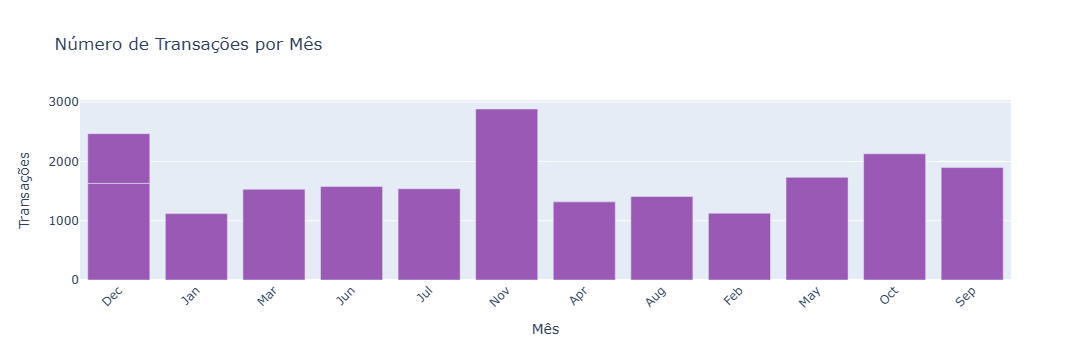

In [50]:
# Transações mensais

transacoes_mensais = df_vendas.groupby(['ano', 'mes_nome']).agg(
    n_transacoes=('InvoiceNo', 'nunique')
).reset_index()

transacoes_mensais['mes_pedido'] = pd.Categorical(transacoes_mensais['mes_nome'], categories=meses, ordered=True)
transacoes_mensais = transacoes_mensais.sort_values(['ano', 'mes_pedido'])

fig = go.Figure()

fig.add_trace(go.Bar(
    x=transacoes_mensais['mes_nome'],
    y=transacoes_mensais['n_transacoes'],
    marker_color='#9b59b6',
    hovertemplate='%{y} transações<br><extra>%{x}</extra>'
))

fig.update_layout(
    title='Número de Transações por Mês',
    xaxis_title='Mês',
    yaxis_title='Transações',
    xaxis_tickangle=-45
)

fig.show()

<div id="produtos"></div>

## 3. Análise de Produtos

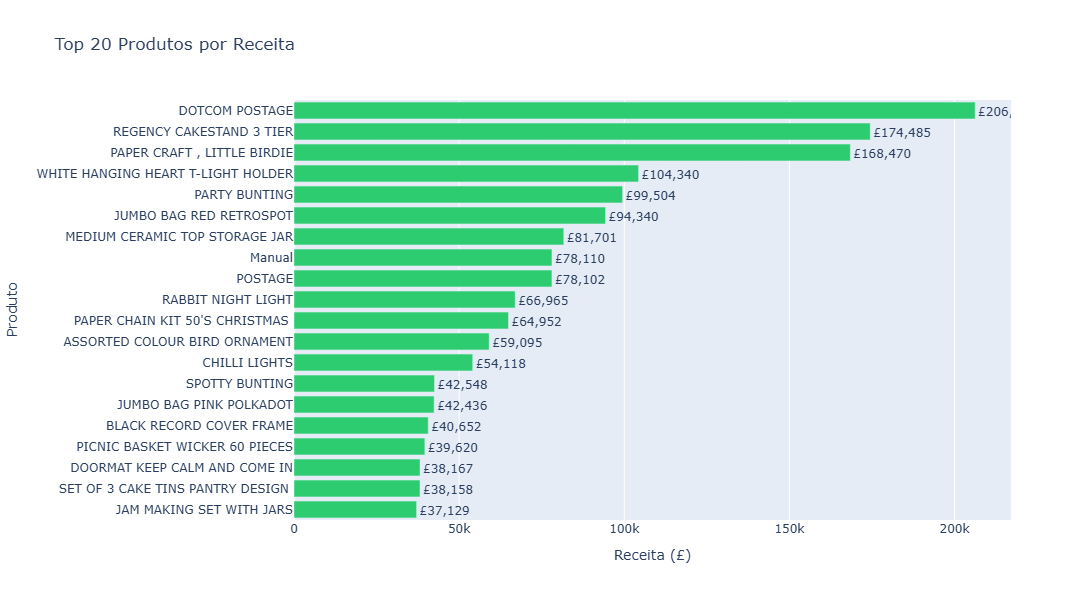

In [52]:
# Top 20 produtos por receita

top_produtos_receita = df_vendas.groupby(['StockCode', 'Description']).agg(
    receita=('total', 'sum'),
    quantidade=('Quantity', 'sum'),
    n_transacoes=('InvoiceNo', 'nunique')
).reset_index().sort_values('receita', ascending=False).head(20)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=top_produtos_receita['receita'],
    y=top_produtos_receita['Description'],
    orientation='h',
    marker_color='#2ecc71',
    text=[f'£{x:,.0f}' for x in top_produtos_receita['receita']],
    textposition='outside'
))

fig.update_layout(
    title='Top 20 Produtos por Receita',
    xaxis_title='Receita (£)',
    yaxis_title='Produto',
    yaxis={'categoryorder': 'total ascending'},
    height=600
)

fig.show()

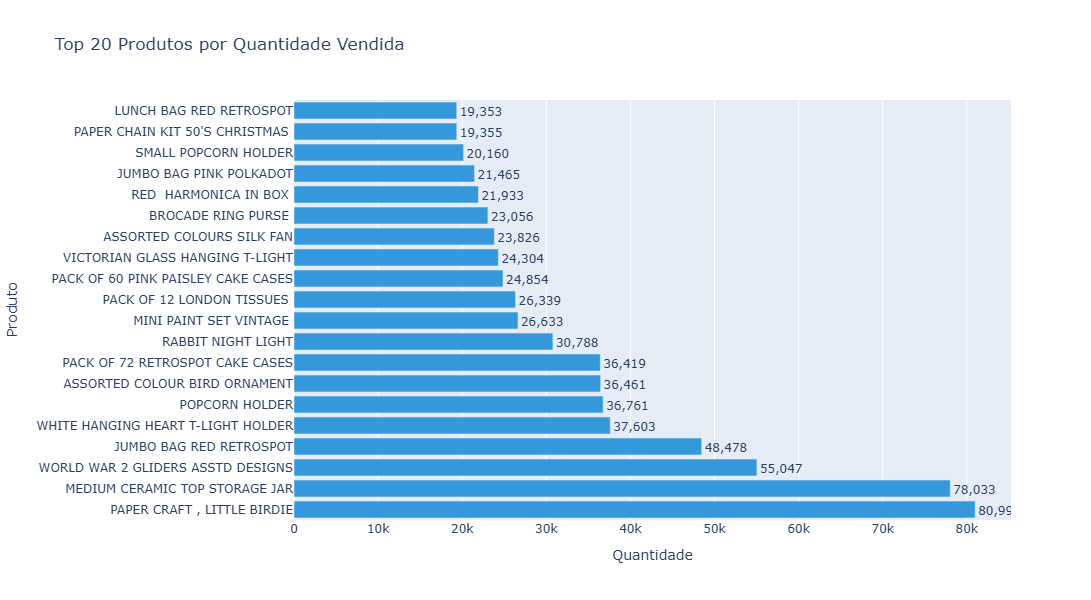

In [55]:
# Top 20 por quantidade

top_produtos_qtd = df_vendas.groupby(['StockCode', 'Description']).agg(
    quantidade=('Quantity', 'sum')
).reset_index().sort_values('quantidade', ascending=False).head(20)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=top_produtos_qtd['quantidade'],
    y=top_produtos_qtd['Description'],
    orientation='h',
    marker_color='#3498db',
    text=[f'{x:,.0f}' for x in top_produtos_qtd['quantidade']],
    textposition='outside'
))

fig.update_layout(
    title='Top 20 Produtos por Quantidade Vendida',
    xaxis_title='Quantidade',
    yaxis_title='Produto',
    height=600
)

fig.show()

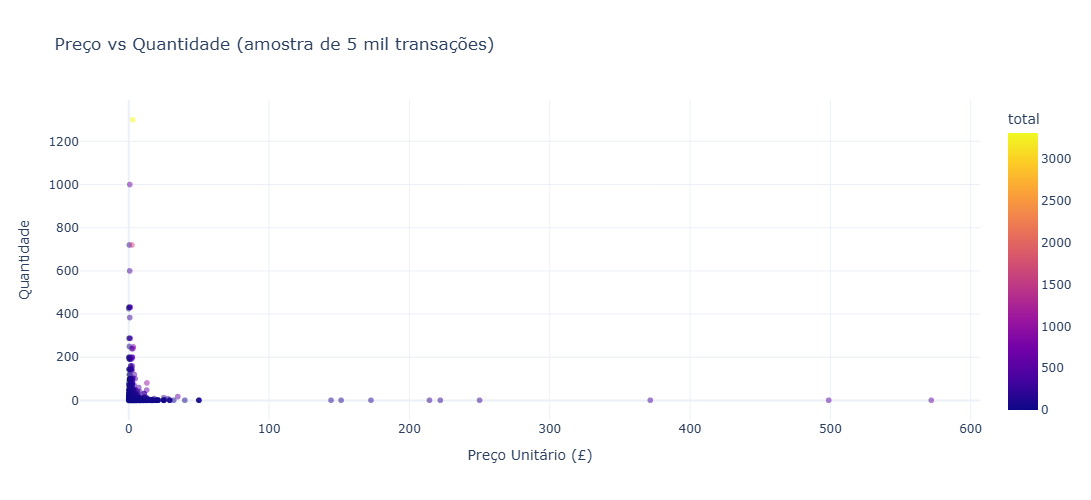

In [64]:
# Vamos fazer um scatter com uma amostra, pois 540k de dados é muita coisa para esse tipo de gráfico

df_amostra = df_vendas.sample(n=5000, random_state=42)

fig = px.scatter(
    df_amostra,
    x='UnitPrice',
    y='Quantity',
    color='total',
    labels={'UnitPrice': 'Preço Unitário (£)', 'Quantity': 'Quantidade'},
    title='Preço vs Quantidade (amostra de 5 mil transações)',
    template='plotly_white'
)

fig.update_traces(marker=dict(size=6, opacity=0.5))

fig.show()

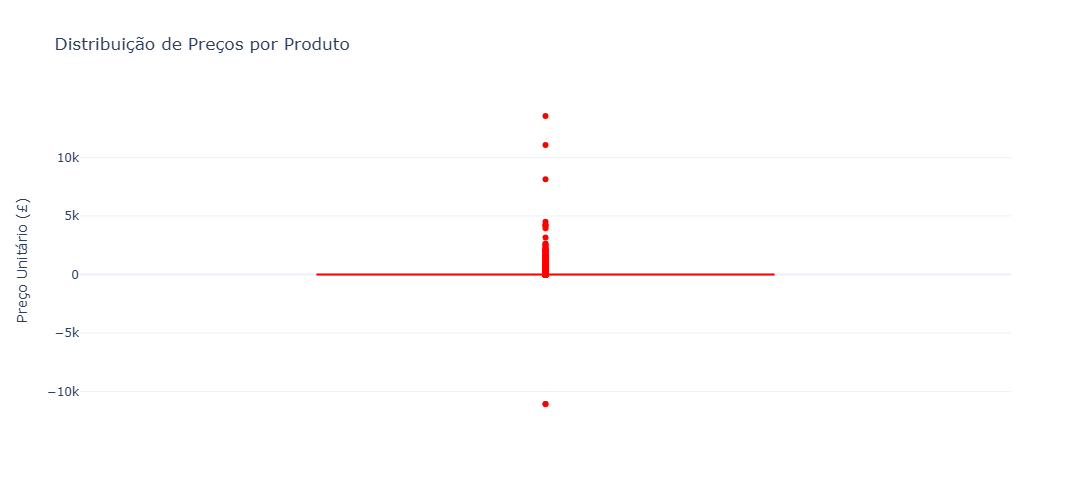

In [62]:
# Box plot da distribuição de preços

fig = px.box(
    df_vendas,
    y='UnitPrice',
    labels={'UnitPrice': 'Preço Unitário (£)'},
    title='Distribuição de Preços por Produto',
    points='all',
    color_discrete_sequence=['#3498db']
)

fig.update_traces(boxpoints='suspectedoutliers', marker_color='red')

fig.show()

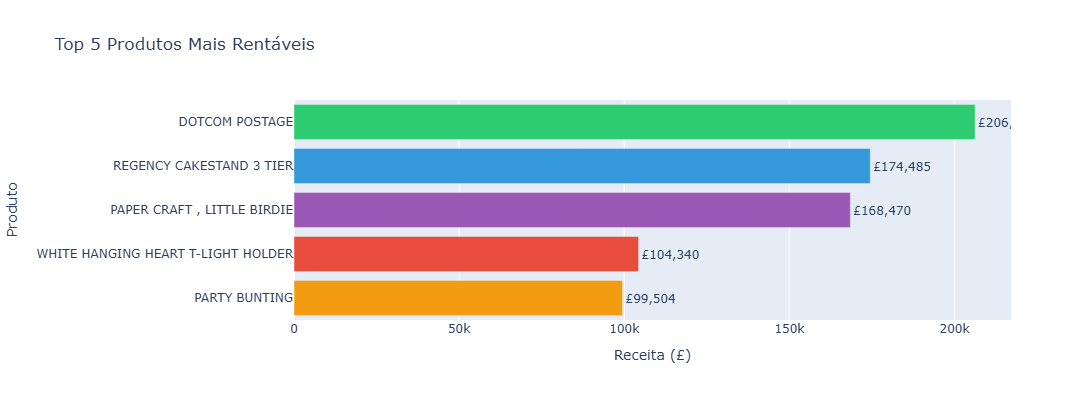

In [63]:
# Top 5 por receita

top5 = top_produtos_receita.head(5)

fig = go.Figure(go.Bar(
    x=top5['receita'],
    y=top5['Description'],
    orientation='h',
    marker_color=['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12'],
    text=[f'£{x:,.0f}' for x in top5['receita']],
    textposition='outside'
))
fig.update_layout(
    title='Top 5 Produtos Mais Rentáveis',
    xaxis_title='Receita (£)',
    yaxis_title='Produto',
    yaxis={'categoryorder': 'total ascending'},
    height=400
)
fig.show()

<div id="geografia"></div>

## 4. Análise Geográfica

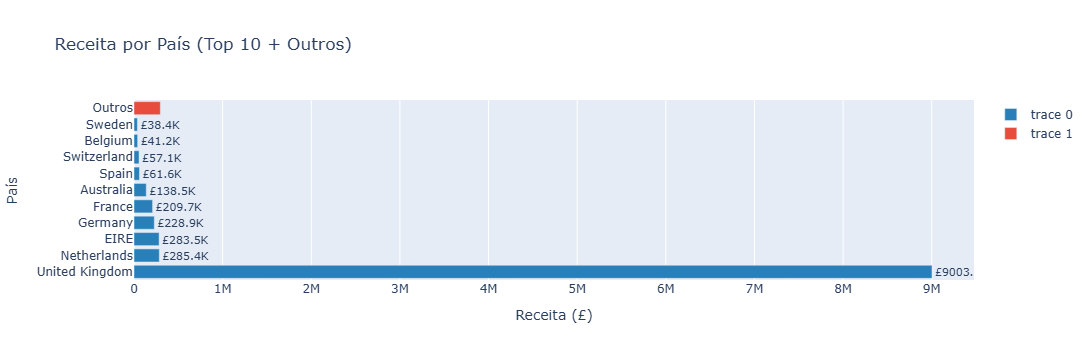


Top países: United Kingdom
Total de países: 38


In [65]:
# Distribuição de vendas por país

geo_receita = df_vendas.groupby('Country').agg(
    receita=('total', 'sum'),
    transacoes=('InvoiceNo', 'nunique'),
    clientes=('CustomerID', 'nunique')
).reset_index().sort_values('receita', ascending=False).head(10)

outros_receita = df_vendas.groupby('Country')['total'].sum().reset_index()[:]
outros_receita = outros_receita[~outros_receita['Country'].isin(geo_receita['Country'].values)]
outros_receita.columns = ['Country', 'receita']
outros_receita['receita'] = outros_receita['receita'].sum()

fig = go.Figure()

fig.add_trace(go.Bar(
    x=geo_receita['receita'],
    y=geo_receita['Country'],
    orientation='h',
    marker_color='#2980b9',
    text=[f'£{x/1000:.1f}K' for x in geo_receita['receita']],
    textposition='outside'
))

fig.add_trace(go.Bar(
    x=[outros_receita['receita'].values[0] if len(outros_receita) > 0 else 0],
    y=['Outros'],
    orientation='h',
    marker_color='#e74c3c'
))

fig.update_layout(
    title='Receita por País (Top 10 + Outros)',
    xaxis_title='Receita (£)',
    yaxis_title='País'
)

fig.show()

print(f"\nTop países: {geo_receita.iloc[0]['Country']}")
print(f"Total de países: {df_vendas['Country'].nunique()}")

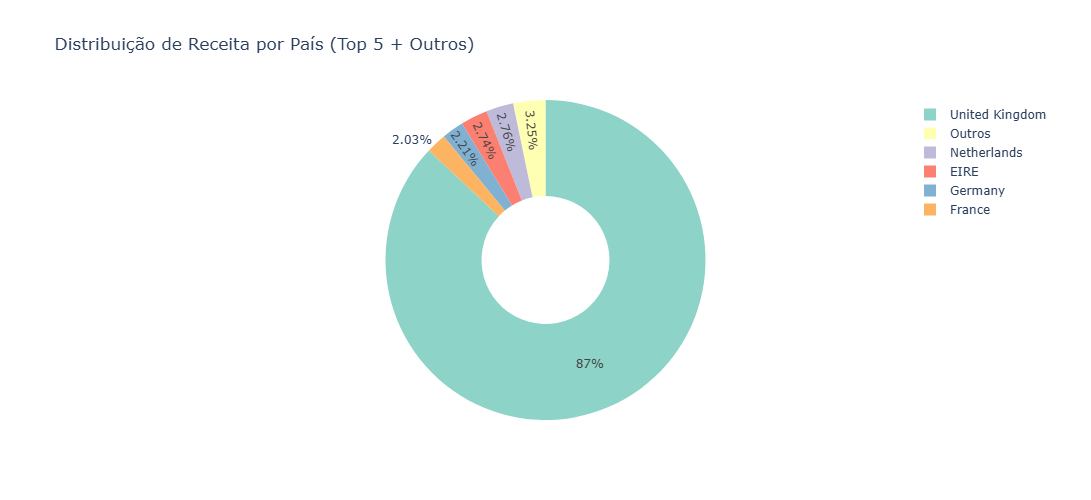

In [67]:
# Gráfico de rosca

top_paises = geo_receita.head(5)
receita_outros = geo_receita['receita'].sum() - top_paises['receita'].sum()

donut_data = [
    top_paises['Country'],
    *top_paises['receita'].values,
    top_paises['receita'].values / top_paises['receita'].sum() * 100
]

fig = px.pie(
    values=[*top_paises['receita'].values, receita_outros],
    names=[*top_paises['Country'].values, 'Outros'],
    title='Distribuição de Receita por País (Top 5 + Outros)',
    hole=0.4,
    color_discrete_sequence=px.colors.qualitative.Set3
)
fig.show()

<div id="cancelamentos"></div>

## 5. Análise de Cancelamentos

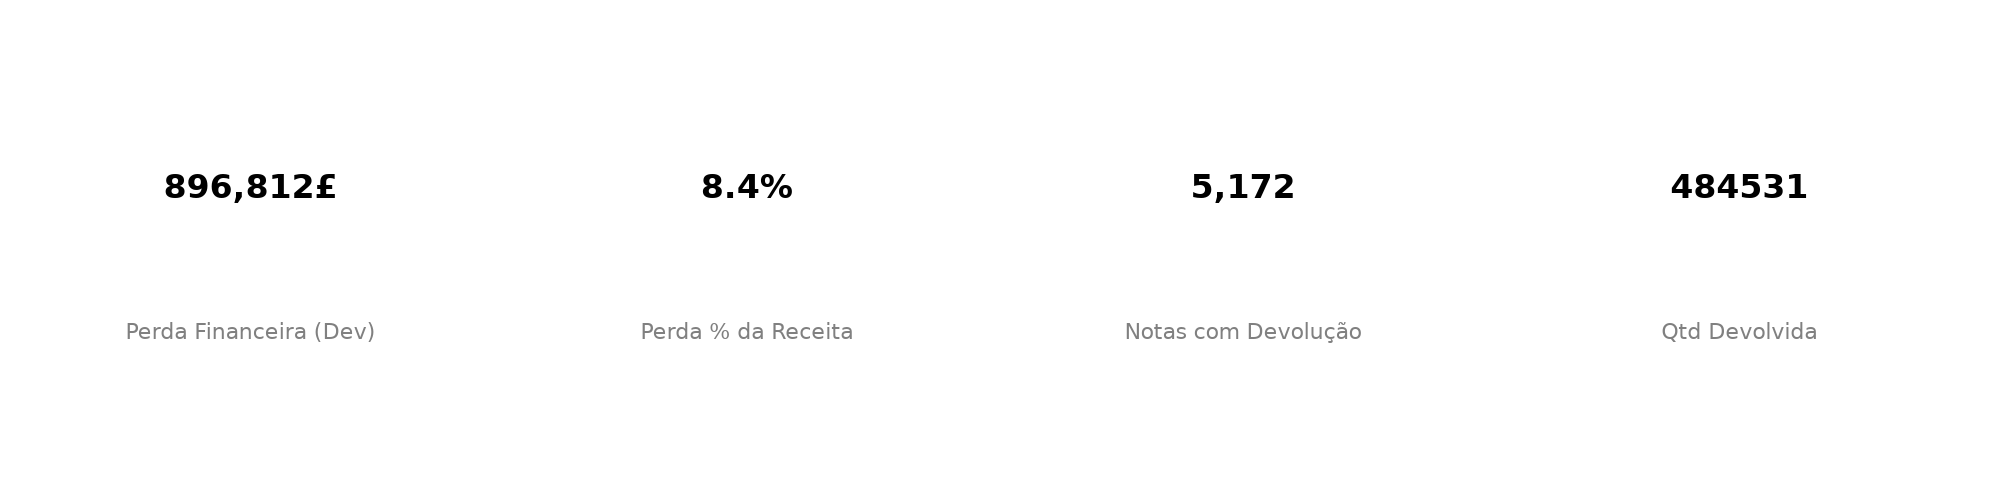

In [69]:
# KPIs das devoluções

total_qtd_dev = abs(df_devolucoes['Quantity'].sum())
n_dev = df_devolucoes['InvoiceNo'].nunique()
perda_val = abs(df_devolucoes['total'].sum())
perda_pct = abs(perda_val / df_vendas['total'].sum() * 100)

fig, axes = plt.subplots(1, 4, figsize=(20,5))

kpis = [
    (f'{perda_val:,.0f}£', 'Perda Financeira (Dev)'),
    (f'{perda_pct:.1f}%', 'Perda % da Receita'),
    (f'{n_dev:,}', 'Notas com Devolução'),
    (f'{total_qtd_dev}', 'Qtd Devolvida')
]

for ax, (valor, titulo) in zip(axes, kpis):
    ax.text(0.5, 0.6, valor, fontsize=24, fontweight='bold', ha='center')
    ax.text(0.5, 0.3, titulo, fontsize=16, ha='center', color='gray')
    ax.set_axis_off()

plt.tight_layout()

plt.show()

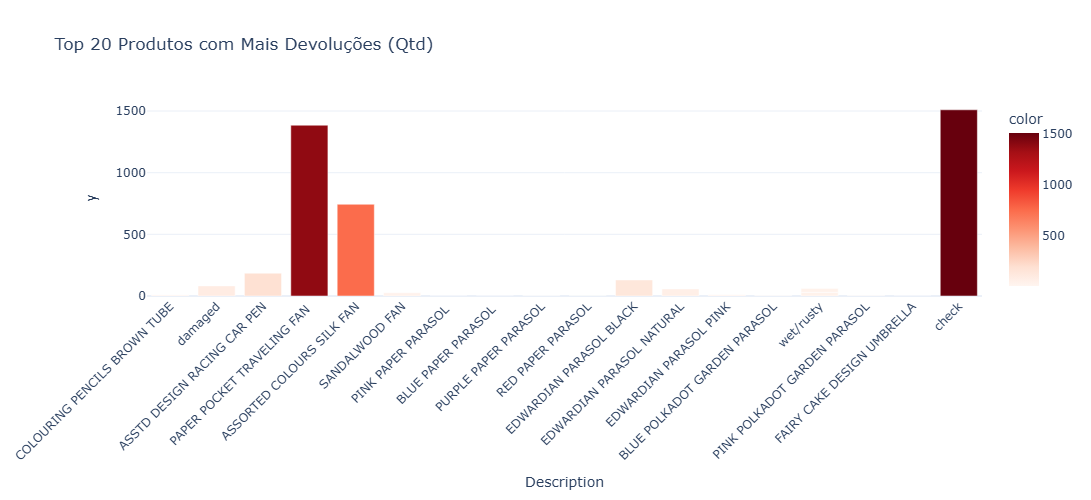

In [73]:
# Produtos mais devolvidos

top_dev = df_devolucoes.groupby(['StockCode', 'Description']).agg(
    qtd_dev=('Quantity', 'sum'),
    n_dev=('InvoiceNo', 'nunique'),
    perda=('total', 'sum')
).reset_index()

top_dev_n = top_dev.head(20)

fig = px.bar(
    top_dev_n,
    x='Description',
    y=abs(top_dev_n['qtd_dev']),
    title='Top 20 Produtos com Mais Devoluções (Qtd)',
    labels={'qtd_dev': 'Quantidade Devolvida'},
    color=abs(top_dev_n['qtd_dev']),
    color_continuous_scale='Reds'
)

fig.update_layout(xaxis_tickangle=-45, height=500)

fig.show()

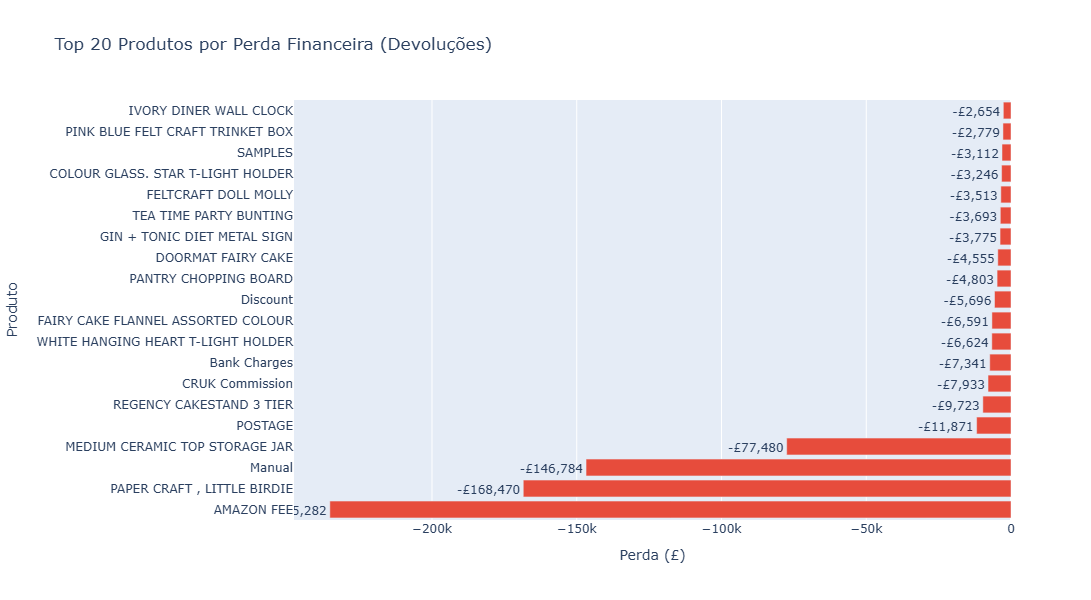

In [76]:
# Produtos por perda financeira
# Top produtos por perda financeira
top_dev_perda = top_dev.sort_values('perda').head(20)

fig = go.Figure(go.Bar(
    x=top_dev_perda['perda'],
    y=top_dev_perda['Description'],
    orientation='h',
    marker_color='#e74c3c',
    text=[f'-£{abs(x):,.0f}' for x in top_dev_perda['perda']],
    textposition='outside'
))

fig.update_layout(
    title='Top 20 Produtos por Perda Financeira (Devoluções)',
    xaxis_title='Perda (£)',
    yaxis_title='Produto',
    height=600
)

fig.show()

<div id="dia-semana"></div>

## 6. Análise por Dia da Semana

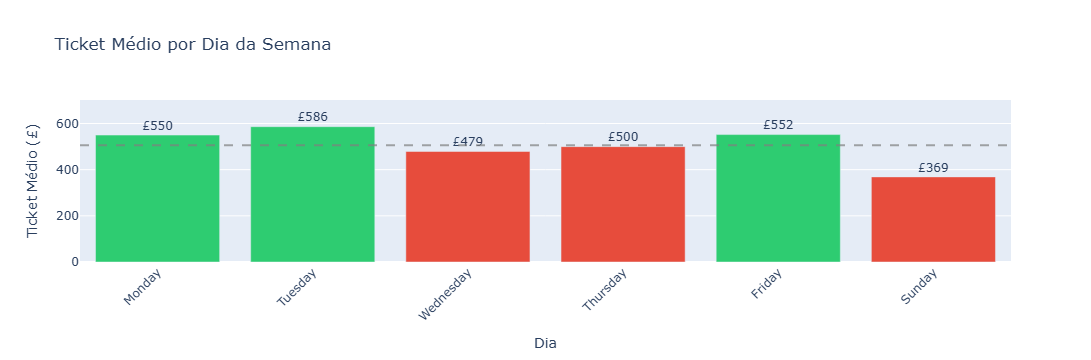

In [88]:
# Ticket médio

ticket_dia = df_vendas.groupby('dia_nome').apply(lambda x: x.groupby('InvoiceNo')['total'].sum().mean()).reset_index()
ticket_dia.columns = ['dia_nome', 'ticket']

fig = go.Figure(go.Bar(
    x=ticket_dia['dia_nome'],
    y=ticket_dia['ticket'],
    marker_color=['#2ecc71' if x > ticket_dia['ticket'].mean() else '#e74c3c' for x in ticket_dia['ticket']],
    text=[f'£{x:,.0f}' for x in ticket_dia['ticket']],
    textposition='outside'
))
fig.update_layout(
    title='Ticket Médio por Dia da Semana',
    xaxis_title='Dia',
    yaxis_title='Ticket Médio (£)',
    xaxis_tickangle=-45
)

fig.add_hline(y=ticket_dia['ticket'].mean(), line_dash='dash', line_color='gray', opacity=0.7)

fig.show()

<div id="clientes-ativos"></div>

## 7. Cliente Ativo ao Longo do Tempo

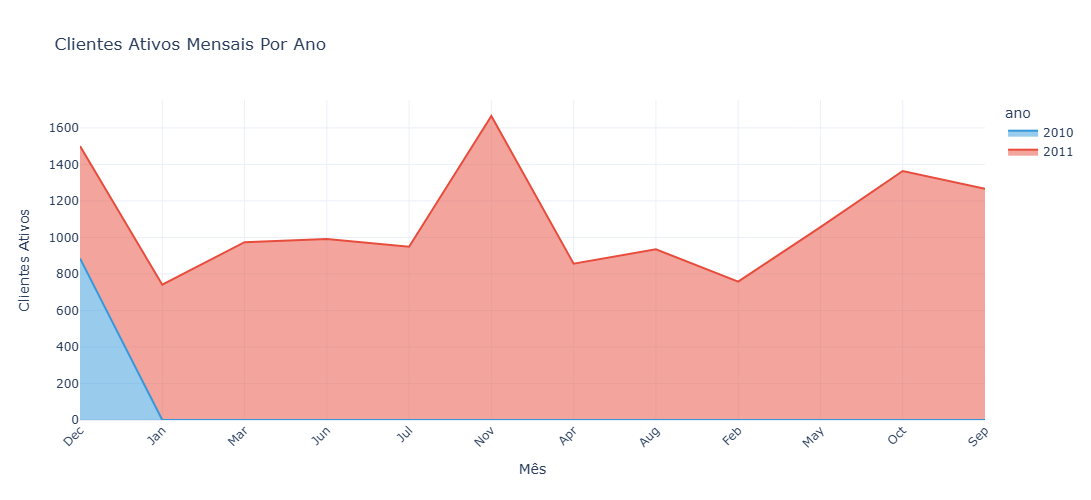

In [95]:

df_vendas['mes-nome'] = df_vendas['InvoiceDate'].dt.strftime('%b')
df_vendas['ano'] = df_vendas['InvoiceDate'].dt.year


clientes_mensais = df_vendas.groupby(['ano', 'mes-nome'])['CustomerID'].nunique().reset_index()
clientes_mensais['mes_order'] = pd.Categorical(clientes_mensais['mes-nome'], categories=meses, ordered=True)
clientes_mensais = clientes_mensais.sort_values(['ano', 'mes_order'])

fig = px.area(
    clientes_mensais,
    x='mes-nome',
    y='CustomerID',
    color='ano',
    title='Clientes Ativos Mensais Por Ano',
    labels={'mes-nome': 'Mês', 'CustomerID': 'Clientes Ativos'},
    color_discrete_sequence=['#3498db', '#e74c3c']
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()

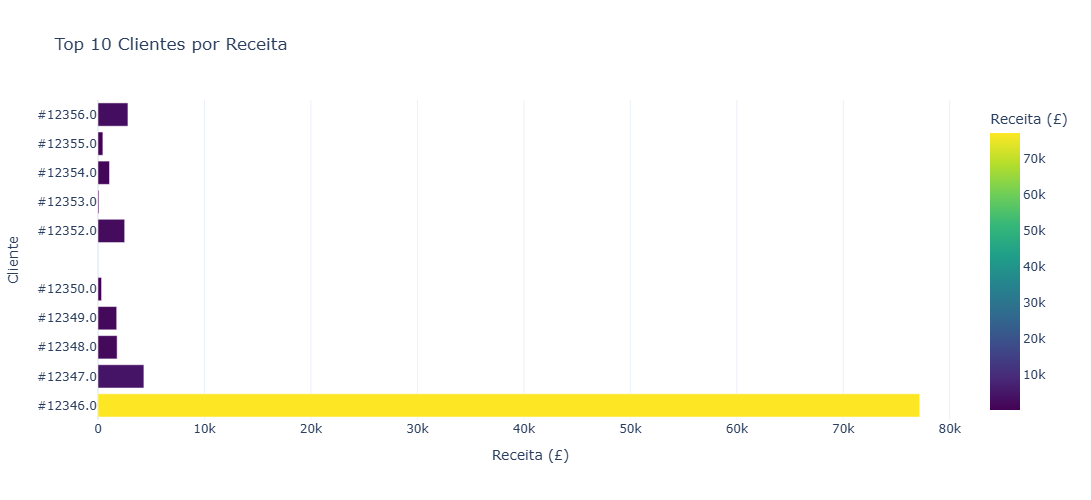

In [97]:
# Top 10 clientes por receita

df_receita = df_vendas.groupby('CustomerID').agg(
    receita=('total', 'sum'),
    transacoes=('InvoiceNo', 'nunique'),
    quantidade=('Quantity', 'sum')
).reset_index()

top_clients = df_full_revenue.head(10)

fig = px.bar(
    top_clients,
    x='receita',
    y=top_clients['CustomerID'],
    orientation='h',
    labels={'CustomerID': 'Cliente', 'receita': 'Receita (£)'},
    color='receita',
    title='Top 10 Clientes por Receita',
    color_continuous_scale='Viridis'
)

fig.update_yaxes(tickmode='array', tickvals=top_clients['CustomerID'], ticktext=[f'#{x}' for x in top_clients['CustomerID']])

fig.show()

<div id="insights"></div>

## 8. Insights

In [100]:
total_receita = df_vendas['total'].sum()
total_devolvido = abs(df_devolucoes['total'].sum())
margem_real = total_receita - total_devolvido


top_produtos = df_vendas.groupby('Description')['total'].sum().sort_values(ascending=False).head(5)


taxa_devolucao_item = (len(df_devolucoes) / len(df_vendas)) * 100
taxa_devolucao_valor = (total_devolvido / total_receita) * 100


top_paises = df_vendas.groupby('Country')['total'].sum().nlargest(3)

print(f"---RESUMO DO NEGÓCIO---")
print(f"Receita Bruta: £{total_receita:,.2f}")
print(f"Perda com Devoluções: £{total_devolvido:,.2f} ({taxa_devolucao_valor:.1f}%)")
print(f"15% da Receita vem de 4 produtos: {top_produtos.sum()/total_receita*100:.1f}%")

display(top_produtos)

---RESUMO DO NEGÓCIO---
Receita Bruta: £10,644,560.42
Perda com Devoluções: £896,812.49 (8.4%)
15% da Receita vem de 4 produtos: 7.1%


Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
Name: total, dtype: float64